In [22]:
# Run this once (if using Colab, it's already installed)
# %pip install seaborn pandas matplotlib numpy  # Skip if already installed

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Make charts look clean and professional
sns.set_style("whitegrid")      # Clean background
sns.set_palette("viridis")      # Nice color scheme
plt.rcParams['figure.figsize'] = (10, 6)  # Default chart size

print("✅ Seaborn ready!")

✅ Seaborn ready!


In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Fix for Rupee symbol (₹) warning - especially important on macOS
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# Optional: Try to use a font that supports ₹ (Arial Unicode or system default)
import matplotlib.font_manager as fm
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans', 'Arial', 'sans-serif']

# Create / Load the dataset
np.random.seed(42)
locations = ['Andheri West', 'Bandra West', 'Juhu', 'Santacruz West', 'Khar West', 'Bandra East', 'Versova']

data = {
    'BHK': np.random.choice([1, 2, 3, 4], 800, p=[0.15, 0.45, 0.3, 0.1]),
    'Locality': np.random.choice(locations, 800),
    'Area_sqft': np.random.normal(1100, 350, 800).astype(int).clip(600, 2500),
    'Price_Lakhs': np.random.normal(450, 280, 800).astype(int).clip(100, 3000),
    'Status': np.random.choice(['Ready to Move', 'Under Construction'], 800),
    'Age': np.random.choice(['0-1 Year', '1-5 Years', '5-10 Years', '10+ Years'], 800)
}

df = pd.DataFrame(data)

# Make prices realistic (premium areas cost more)
premium = ['Bandra West', 'Juhu', 'Khar West']
df.loc[df['Locality'].isin(premium), 'Price_Lakhs'] += 200
df['Price_Lakhs'] = (df['Price_Lakhs'] + (df['Area_sqft'] * 0.4) + (df['BHK'] * 80)).astype(int).clip(100, 3000)

# Set clean Seaborn theme
sns.set_theme(style="whitegrid", palette="pastel", font_scale=1.1)

print("✅ Dataset ready! Shape:", df.shape)
print(df.head())

✅ Dataset ready! Shape: (800, 6)
   BHK        Locality  Area_sqft  Price_Lakhs              Status         Age
0    2         Versova       1231         1176       Ready to Move   1-5 Years
1    4     Bandra West        834         1482       Ready to Move  5-10 Years
2    3    Andheri West        624         1121  Under Construction  5-10 Years
3    2  Santacruz West        989         1757       Ready to Move  5-10 Years
4    2         Versova        840          596       Ready to Move  5-10 Years


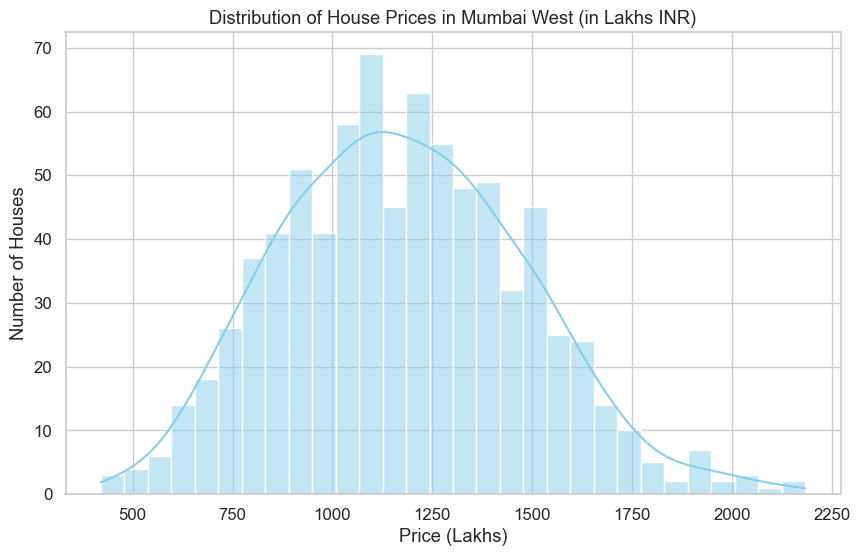

In [25]:
# Step 3: Basic Distribution – How are prices spread out?
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Price_Lakhs', kde=True, bins=30, color='skyblue')
plt.title('Distribution of House Prices in Mumbai West (in Lakhs INR)')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Number of Houses')
plt.show()

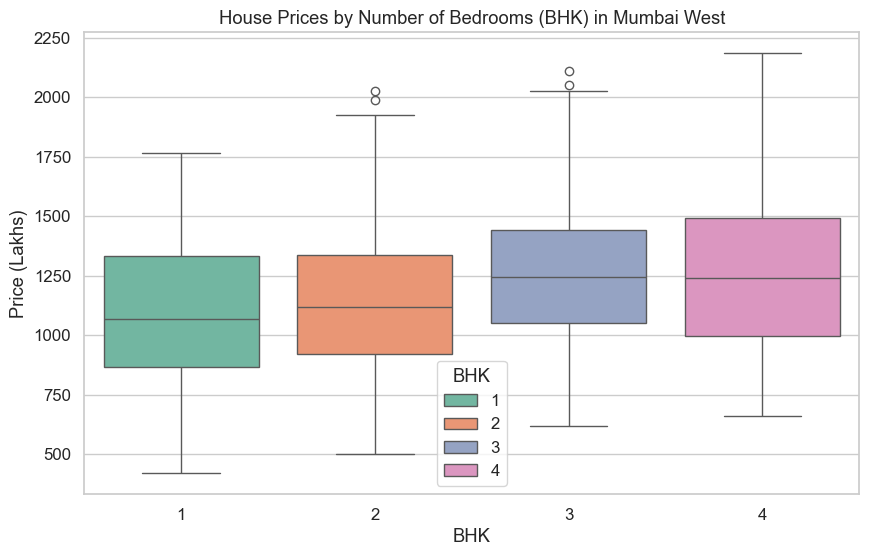

In [26]:
# Step 4: Compare Prices by BHK (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='BHK', y='Price_Lakhs', palette='Set2' , hue='BHK')
plt.title('House Prices by Number of Bedrooms (BHK) in Mumbai West')
plt.xlabel('BHK')
plt.ylabel('Price (Lakhs)')
plt.show()

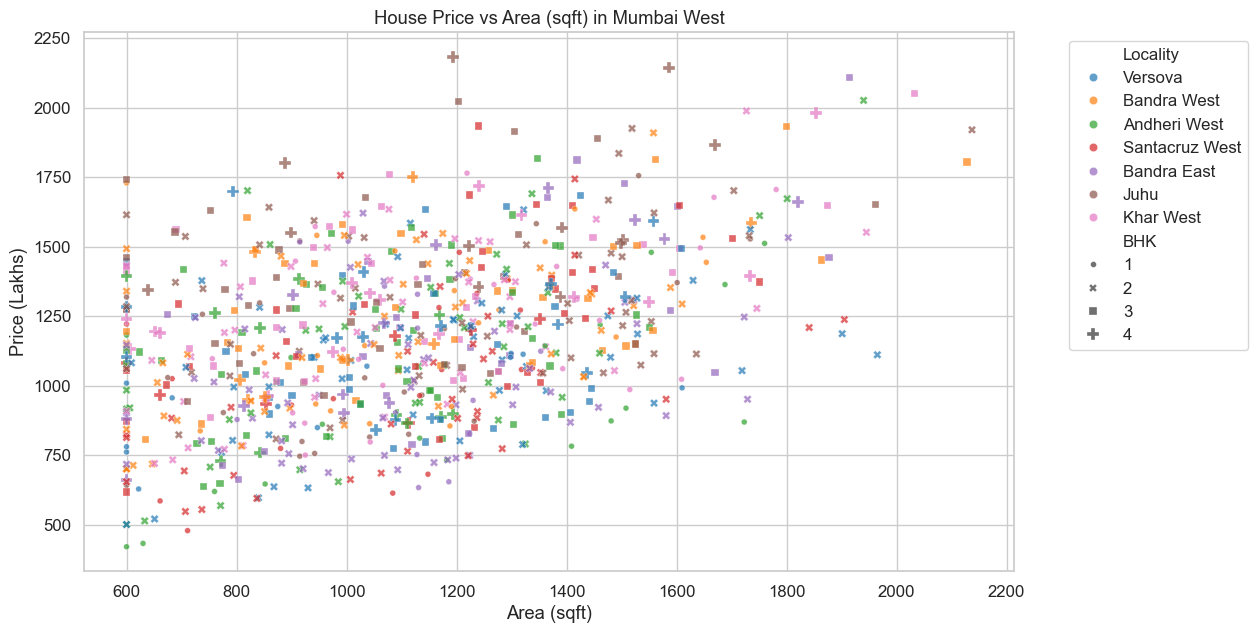

In [27]:
# Step 5: Relationship – Price vs Area (Scatterplot)
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='Area_sqft', y='Price_Lakhs', 
                hue='Locality', style='BHK', size='BHK', 
                palette='tab10', alpha=0.7)
plt.title('House Price vs Area (sqft) in Mumbai West')
plt.xlabel('Area (sqft)')
plt.ylabel('Price (Lakhs)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

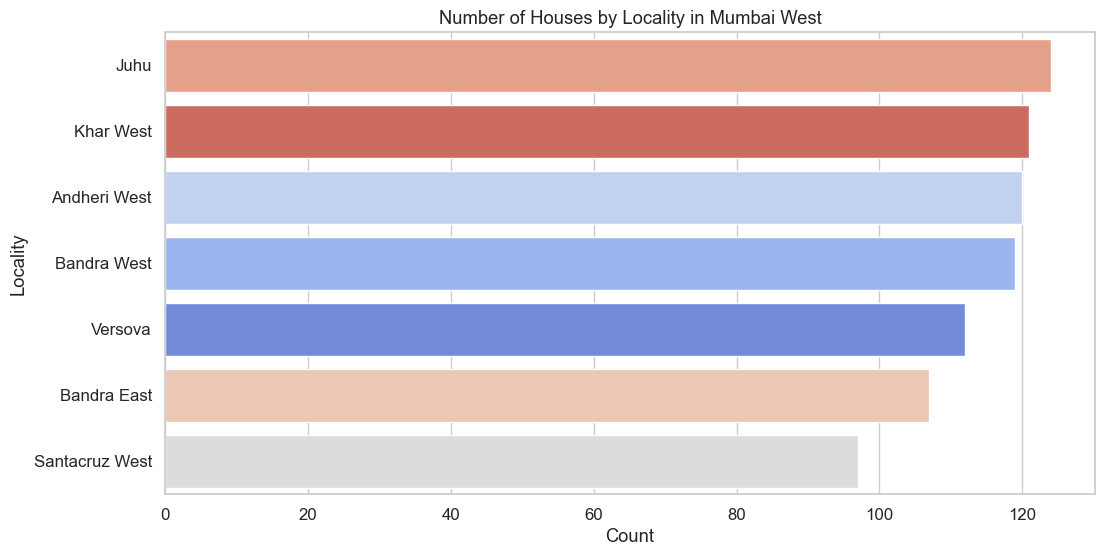

In [28]:
### Step 6: Count of Houses by Locality (Bar Chart)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Locality', 
              order=df['Locality'].value_counts().index, 
              palette='coolwarm',hue='Locality')
plt.title('Number of Houses by Locality in Mumbai West')
plt.xlabel('Count')
plt.ylabel('Locality')
plt.show()

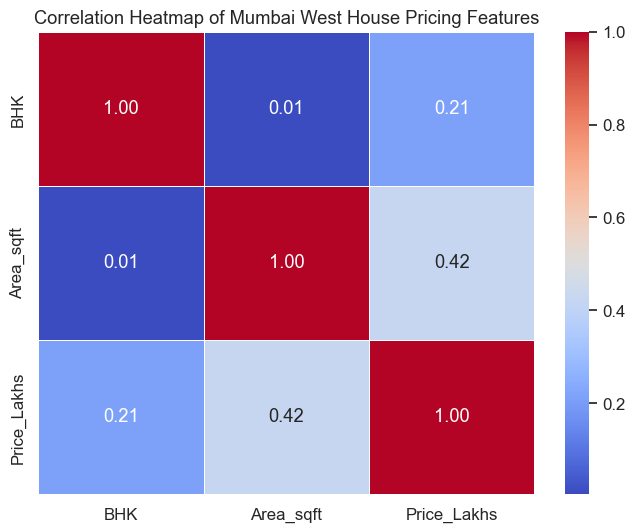

In [29]:
### Step 7: Correlation Heatmap – See relationships at a glance
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Mumbai West House Pricing Features')
plt.show()

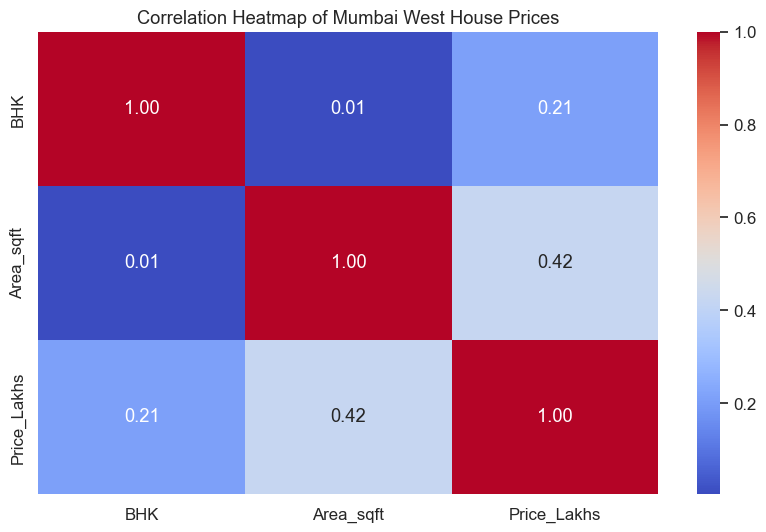

In [30]:
# How we created it
numeric_data = df[['BHK', 'Area_sqft', 'Price_Lakhs']]   # Only number columns
corr_matrix = numeric_data.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Mumbai West House Prices')
plt.show()

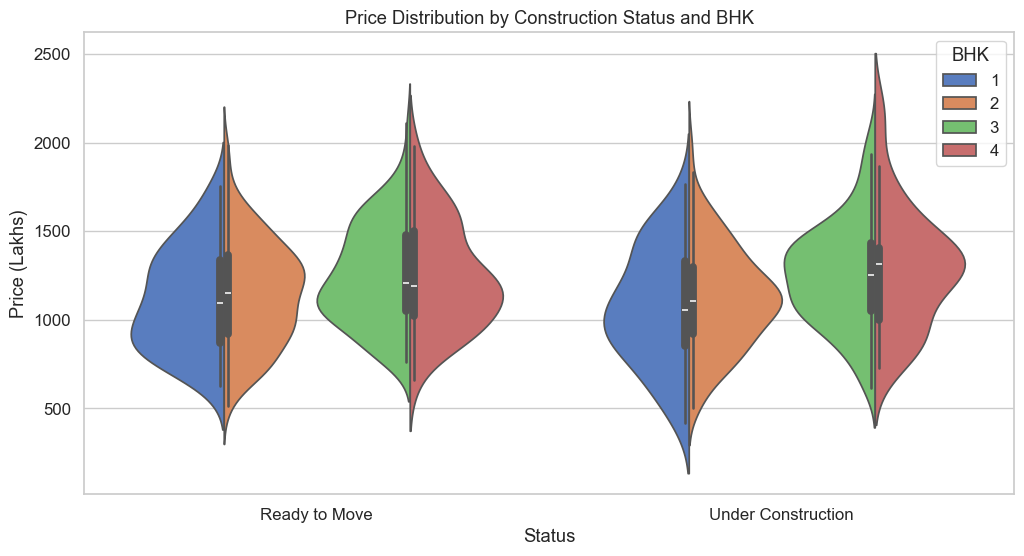

In [31]:
### Step 8: Advanced (but still easy!) – Violin Plot by Status
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Status', y='Price_Lakhs', 
               hue='BHK', split=True, palette='muted')
plt.title('Price Distribution by Construction Status and BHK')
plt.xlabel('Status')
plt.ylabel('Price (Lakhs)')
plt.show()

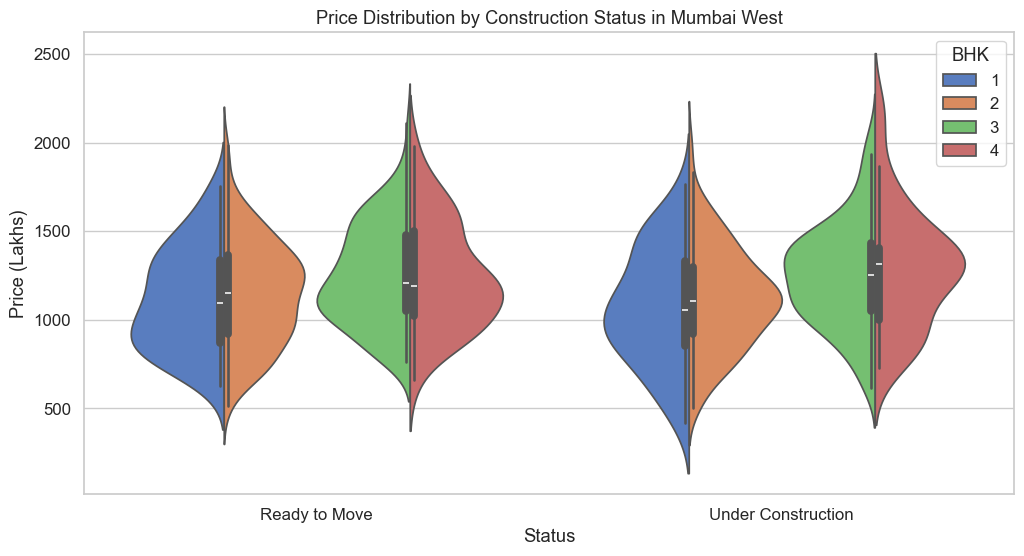

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.violinplot(data=df, 
               x='Status',           # Groups: Ready vs Under Construction
               y='Price_Lakhs',      # What we are comparing: Price
               hue='BHK',            # Optional: color by number of bedrooms
               split=True,           # Nice split view
               palette='muted')

plt.title('Price Distribution by Construction Status in Mumbai West')
plt.xlabel('Status')
plt.ylabel('Price (Lakhs)')
plt.show()

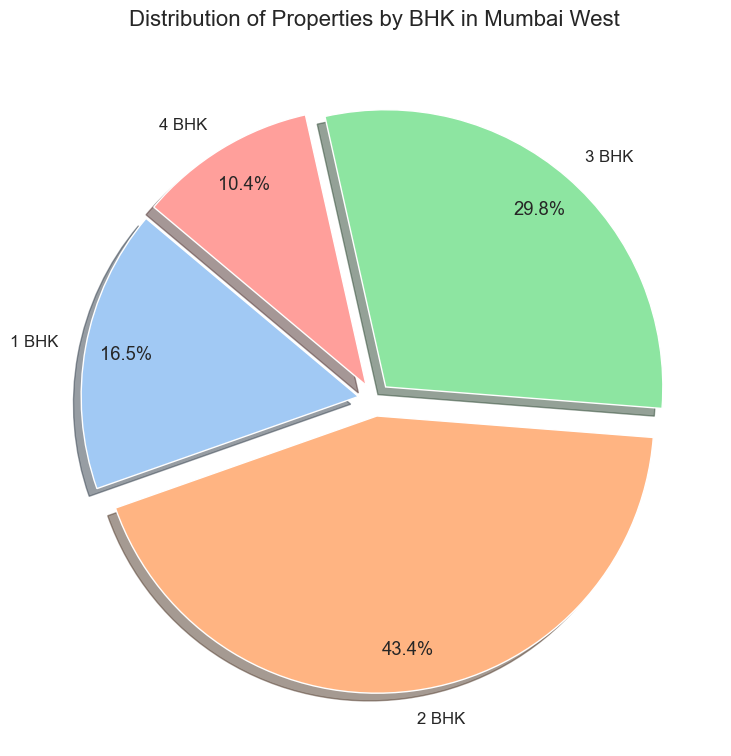

In [33]:
# Learning Outcome 2: Customize pie charts using Matplotlib alongside Seaborn
# Pie Chart: Distribution of Properties by BHK
bhk_counts = df['BHK'].value_counts().sort_index()
labels = [f'{b} BHK' for b in bhk_counts.index]
colors = sns.color_palette("pastel", len(labels))

plt.figure(figsize=(9, 9))
plt.pie(bhk_counts, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=140, explode=[0.06]*len(labels), shadow=True, pctdistance=0.85)

plt.title('Distribution of Properties by BHK in Mumbai West', fontsize=16, pad=20)
plt.show()

/Users/pankajchouhan/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


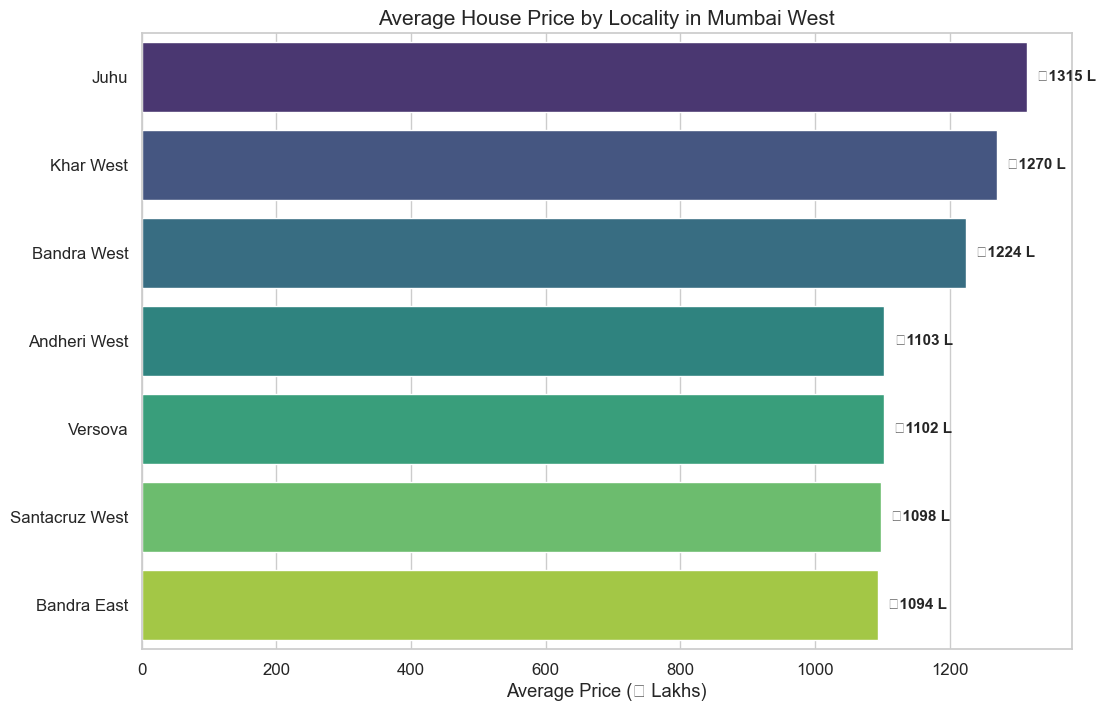

In [34]:
# Learning Outcome 3: Create and enhance horizontal bar charts
# Average price per locality (in Lakhs)
avg_price = df.groupby('Locality')['Price_Lakhs'].mean().reset_index()
avg_price = avg_price.sort_values('Price_Lakhs', ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=avg_price, x='Price_Lakhs', y='Locality', palette="viridis" , hue='Locality')

plt.title('Average House Price by Locality in Mumbai West', fontsize=15)
plt.xlabel('Average Price (₹ Lakhs)')
plt.ylabel('')

# Add value labels
for i, v in enumerate(avg_price['Price_Lakhs']):
    ax.text(v + 15, i, f'₹{v:.0f} L', va='center', fontsize=11, fontweight='bold')

plt.show()

/Users/pankajchouhan/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


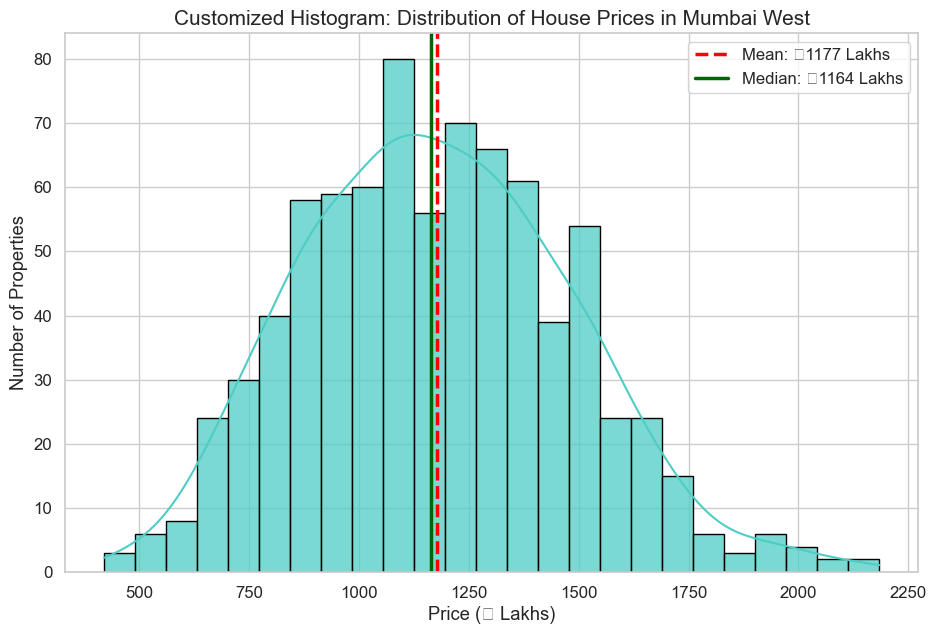

In [35]:
# Learning Outcome 4: Customize histograms for deeper distribution analysis
plt.figure(figsize=(11, 7))
ax = sns.histplot(data=df, x='Price_Lakhs', bins=25, kde=True, 
                  color='#4ECDC4', edgecolor='black', alpha=0.75)

plt.title('Customized Histogram: Distribution of House Prices in Mumbai West', fontsize=15)
plt.xlabel('Price (₹ Lakhs)')
plt.ylabel('Number of Properties')

# Add mean and median lines
mean_p = df['Price_Lakhs'].mean()
median_p = df['Price_Lakhs'].median()

ax.axvline(mean_p, color='red', linestyle='--', linewidth=2.5, label=f'Mean: ₹{mean_p:.0f} Lakhs')
ax.axvline(median_p, color='darkgreen', linestyle='-', linewidth=2.5, label=f'Median: ₹{median_p:.0f} Lakhs')

plt.legend(fontsize=12)
plt.show()

/Users/pankajchouhan/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


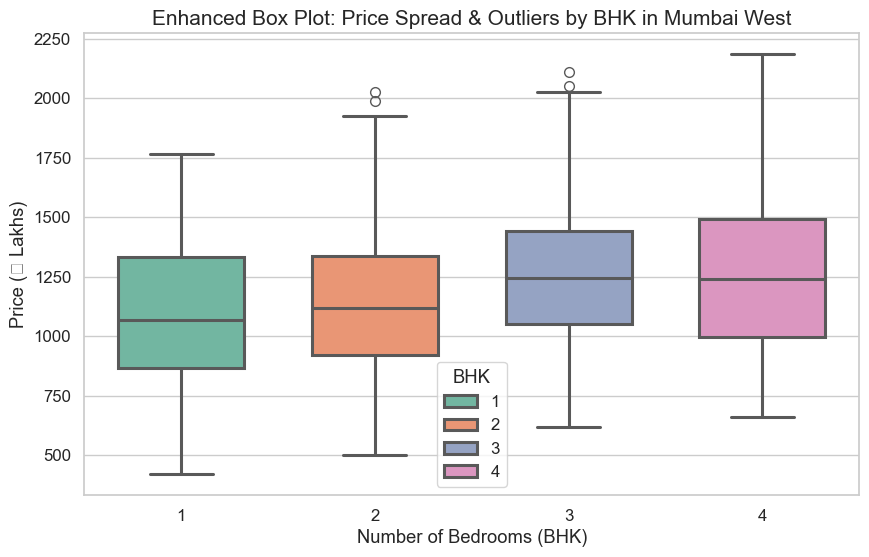

In [36]:
# Learning Outcome 5: Enhance box plots to better interpret spread and outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x='BHK', y='Price_Lakhs', data=df, 
            palette="Set2", width=0.65, fliersize=7, linewidth=2.2,hue='BHK')

plt.title('Enhanced Box Plot: Price Spread & Outliers by BHK in Mumbai West', fontsize=15)
plt.xlabel('Number of Bedrooms (BHK)')
plt.ylabel('Price (₹ Lakhs)')
plt.show()

/var/folders/f3/3kqpjfqj03s00nxsf6rppv280000gn/T/ipykernel_24195/93085572.py:20: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/pankajchouhan/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


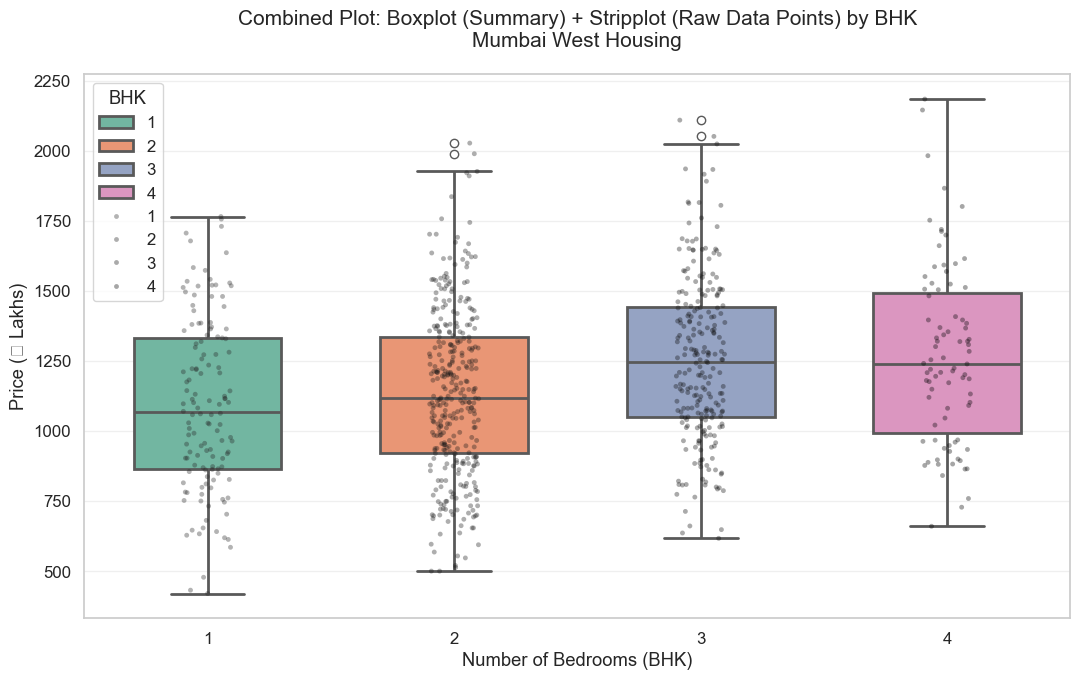

In [40]:
# Learning Outcome 6: Combine multiple plots to reveal both summary statistics and raw data
plt.figure(figsize=(11, 7))

# Boxplot (summary statistics)
ax = sns.boxplot(x='BHK', y='Price_Lakhs', data=df, 
                 palette="Set2", width=0.6, linewidth=2,hue='BHK')

# Stripplot with fixed color parameter (no more FutureWarning)
sns.stripplot(x='BHK', y='Price_Lakhs', data=df, 
              palette='dark:black',   # Fixed: using palette instead of color
              alpha=0.35, jitter=True, size=3.5, ax=ax,hue='BHK')

plt.title('Combined Plot: Boxplot (Summary) + Stripplot (Raw Data Points) by BHK\nMumbai West Housing', fontsize=15, pad=20)
plt.xlabel('Number of Bedrooms (BHK)')
plt.ylabel('Price (₹ Lakhs)')

# Optional: Add grid for better readability
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/f3/3kqpjfqj03s00nxsf6rppv280000gn/T/ipykernel_24195/2038025026.py:15: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/pankajchouhan/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


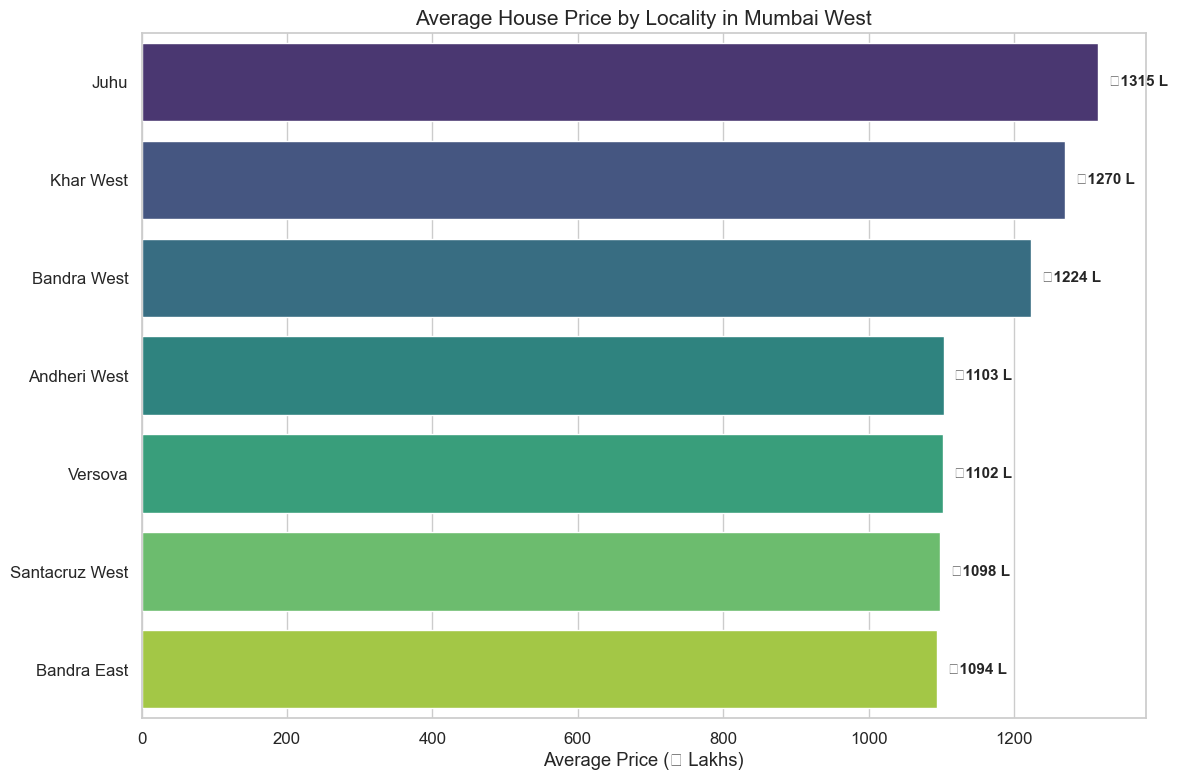

In [43]:
# Other Plots – Small Improvements (Recommended)
avg_price = df.groupby('Locality')['Price_Lakhs'].mean().reset_index()
avg_price = avg_price.sort_values('Price_Lakhs', ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=avg_price, x='Price_Lakhs', y='Locality', palette="viridis",hue='Locality')

plt.title('Average House Price by Locality in Mumbai West', fontsize=15)
plt.xlabel('Average Price (₹ Lakhs)')
plt.ylabel('')

for i, v in enumerate(avg_price['Price_Lakhs']):
    ax.text(v + 15, i, f'₹{v:.0f} L', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

/var/folders/f3/3kqpjfqj03s00nxsf6rppv280000gn/T/ipykernel_24195/167141019.py:16: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/pankajchouhan/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


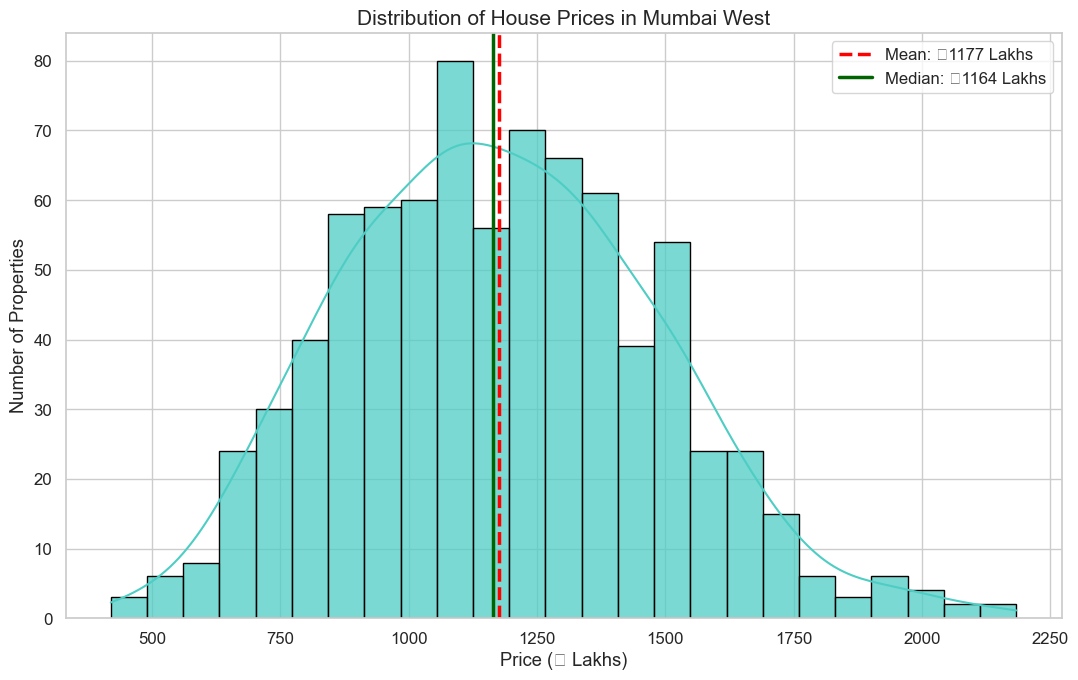

In [44]:
plt.figure(figsize=(11, 7))
ax = sns.histplot(data=df, x='Price_Lakhs', bins=25, kde=True, 
                  color='#4ECDC4', edgecolor='black', alpha=0.75)

plt.title('Distribution of House Prices in Mumbai West', fontsize=15)
plt.xlabel('Price (₹ Lakhs)')
plt.ylabel('Number of Properties')

mean_p = df['Price_Lakhs'].mean()
median_p = df['Price_Lakhs'].median()

ax.axvline(mean_p, color='red', linestyle='--', linewidth=2.5, label=f'Mean: ₹{mean_p:.0f} Lakhs')
ax.axvline(median_p, color='darkgreen', linestyle='-', linewidth=2.5, label=f'Median: ₹{median_p:.0f} Lakhs')

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()